In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import zipfile

zip_path = "/content/drive/MyDrive/CRPF_IMAGES.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [12]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root, len(files))

/content/dataset 0
/content/dataset/3_Specimen image 892
/content/dataset/5_Compression after impact strength 1
/content/dataset/1_Low velocity impact testing condition 0


In [14]:
import os

path = "/content/dataset/1_Low velocity impact testing condition"

for root, dirs, files in os.walk(path):
    print(root)
    print("Dirs:", dirs)
    print("Files:", files)
    print("-"*40)

/content/dataset/1_Low velocity impact testing condition
Dirs: []
Files: []
----------------------------------------


In [15]:
import os

print(os.listdir("/content/dataset/5_Compression after impact strength"))

['Compression after impact strength_v0.2.xlsx']


In [16]:
import pandas as pd

excel_path = "/content/dataset/5_Compression after impact strength/Compression after impact strength_v0.2.xlsx"

df = pd.read_excel(excel_path)

print(df.head())
print(df.columns)

   Unnamed: 0    Unnamed: 1                         Unnamed: 2 Unnamed: 3
0         NaN  Specimen No.  Compression after impact strength        NaN
1         NaN           NaN                              [Mpa]        [%]
2         NaN         c8-6t                         199.801865   0.720235
3         NaN         c8-8t                         216.368547   0.779954
4         NaN         c8-9t                         190.131233   0.685375
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3'], dtype='object')


In [17]:
import pandas as pd

excel_path = "/content/dataset/5_Compression after impact strength/Compression after impact strength_v0.2.xlsx"

df = pd.read_excel(excel_path)

# Drop first 2 rows (junk header + units)
df = df.iloc[2:]

# Rename columns properly
df.columns = ["ignore", "Specimen_ID", "CAI_strength", "Reduction"]

# Drop useless column
df = df.drop(columns=["ignore"])

# Reset index
df = df.reset_index(drop=True)

print(df.head())

  Specimen_ID CAI_strength Reduction
0       c8-6t   199.801865  0.720235
1       c8-8t   216.368547  0.779954
2       c8-9t   190.131233  0.685375
3      c8-10t   204.172332   0.73599
4      c8-11t   262.598682  0.946602


In [18]:
df["Specimen_ID"] = df["Specimen_ID"].str.replace("t", "")

In [19]:
import os

img_folder = "/content/dataset/3_Specimen image"

images = os.listdir(img_folder)

data = []

for img in images:
    specimen_id = img.split(".")[0]

    row = df[df["Specimen_ID"] == specimen_id]

    if len(row) > 0:
        strength = row["CAI_strength"].values[0]
        data.append((img, strength))

print("✅ Matched samples:", len(data))

✅ Matched samples: 0


In [20]:
print("Excel IDs:")
print(df["Specimen_ID"].head(10).tolist())

import os
images = os.listdir("/content/dataset/3_Specimen image")

print("\nImage names:")
print(images[:10])

Excel IDs:
['c8-6', 'c8-8', 'c8-9', 'c8-10', 'c8-11', 'c8-12', 'c24-6', 'c24-8', 'c24-9', 'c24-10']

Image names:
['q16-49_back.jpg', 'c16-23_back.jpg', 'q8-35_back.jpg', 'c8-25_front.jpg', 'q8-28_front.jpg', 'c8-9_back.jpg', 'c8-11_front.jpg', 'q8-28_back.jpg', 'c8-46_front.jpg', 'q8-8_front.jpg']


In [21]:
clean_images = []

for img in images:
    name = img.split(".")[0]

    # Remove suffix
    name = name.replace("_front", "")
    name = name.replace("_back", "")

    name = name.strip().lower()

    clean_images.append((img, name))

In [22]:
data = []

for img, clean_name in clean_images:
    row = df[df["Specimen_ID"] == clean_name]

    if len(row) > 0:
        strength = row["CAI_strength"].values[0]
        data.append((img, strength))

print("✅ Matched samples:", len(data))

✅ Matched samples: 868


In [25]:
import cv2
import numpy as np
import os

IMG_SIZE = 224

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # important
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [26]:
X = []
y = []

for img_name, strength in data:
    path = os.path.join(img_folder, img_name)

    img = preprocess_image(path)

    X.append(img)
    y.append(strength)

X = np.array(X, dtype="float32")
y = np.array(y, dtype="float32")

print("X:", X.shape)
print("y:", y.shape)

X: (868, 224, 224, 3)
y: (868,)


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
y = scaler.fit_transform(y.reshape(-1,1))

In [28]:
from sklearn.model_selection import train_test_split

# Train + temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2)

# Validation + test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (694, 224, 224, 3)
Val: (87, 224, 224, 3)
Test: (87, 224, 224, 3)


In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [30]:
import tensorflow as tf

BATCH_SIZE = 16

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

In [31]:
print("Sample input:", X_train[0].shape)
print("Sample label:", y_train[0])

Sample input: (224, 224, 3)
Sample label: [0.32131028]


In [32]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pretrained model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base (important initially)
base_model.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1)(x)   # regression

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [33]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 742ms/step - loss: 2.1355 - mae: 1.1370 - val_loss: 0.2583 - val_mae: 0.3891
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 624ms/step - loss: 2.2821 - mae: 1.1855 - val_loss: 0.4444 - val_mae: 0.5722
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 664ms/step - loss: 1.4612 - mae: 0.9497 - val_loss: 0.1768 - val_mae: 0.3475
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 655ms/step - loss: 1.0094 - mae: 0.7829 - val_loss: 0.1027 - val_mae: 0.2532
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 665ms/step - loss: 0.5312 - mae: 0.5753 - val_loss: 0.1413 - val_mae: 0.2937
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 642ms/step - loss: 0.3380 - mae: 0.4499 - val_loss: 0.0974 - val_mae: 0.2483
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 666ms/step - loss: 0.2146 - mae: 0.3641 - val_loss: 0.0671 - val_mae: 0.2123
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 660ms/step - loss: 0.1767 - mae: 0.3287 - val_loss: 0.0764 - val_mae: 0.2207
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 640ms/

In [34]:
# Unfreeze top layers
base_model.trainable = True

for layer in base_model.layers[:-30]:   # freeze most layers
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # low LR
    loss='mse',
    metrics=['mae']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 57s 978ms/step - loss: 0.3336 - mae: 0.4393 - val_loss: 0.1039 - val_mae: 0.2727
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 912ms/step - loss: 0.2150 - mae: 0.3620 - val_loss: 0.1869 - val_mae: 0.3749
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 883ms/step - loss: 0.1731 - mae: 0.3231 - val_loss: 0.2355 - val_mae: 0.4280
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 915ms/step - loss: 0.1458 - mae: 0.2930 - val_loss: 0.2786 - val_mae: 0.4655
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 921ms/step - loss: 0.1359 - mae: 0.2839 - val_loss: 0.2962 - val_mae: 0.4790
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 869ms/step - loss: 0.1327 - mae: 0.2772 - val_loss: 0.3057 - val_mae: 0.4844
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 922ms/step - loss: 0.1083 - mae: 0.2561 - val_loss: 0.3476 - val_mae: 0.5148
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 917ms/step - loss: 0.1091 - mae: 0.2540 - val_loss: 0.3218 - val_mae: 0.4950
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 926ms/

In [35]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

# Reverse normalization
pred = scaler.inverse_transform(pred)
y_test_real = scaler.inverse_transform(y_test)

print("R2 Score:", r2_score(y_test_real, pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
R2 Score: -3.3144116401672363


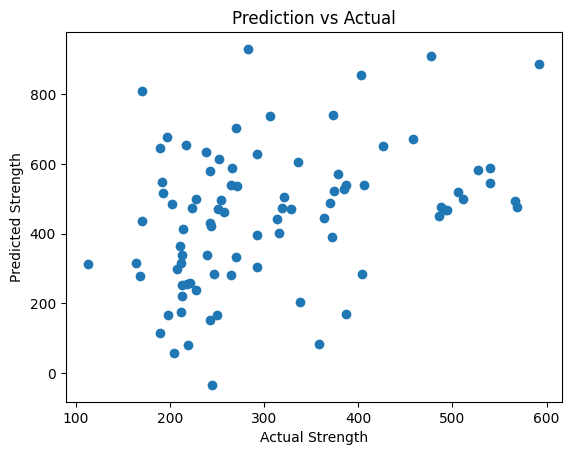

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y_test_real, pred)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Prediction vs Actual")
plt.show()

In [37]:
model.save("/content/cfrp_model.h5")

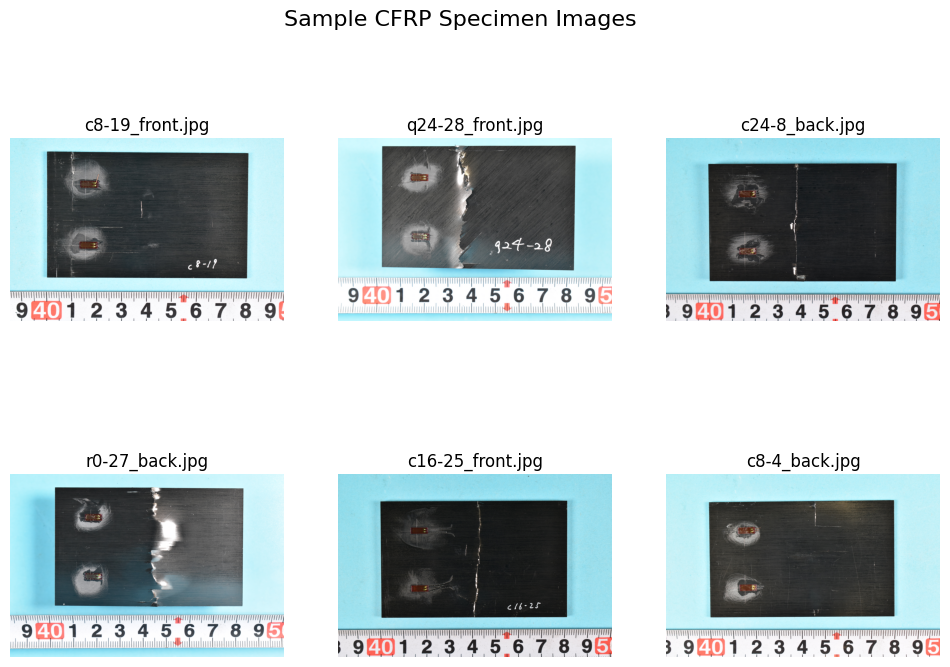

In [38]:
import matplotlib.pyplot as plt
import random
import os
import cv2

img_folder = "/content/dataset/3_Specimen image"

plt.figure(figsize=(12,8))

for i in range(6):
    img_name = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.suptitle("Sample CFRP Specimen Images", fontsize=16)
plt.show()

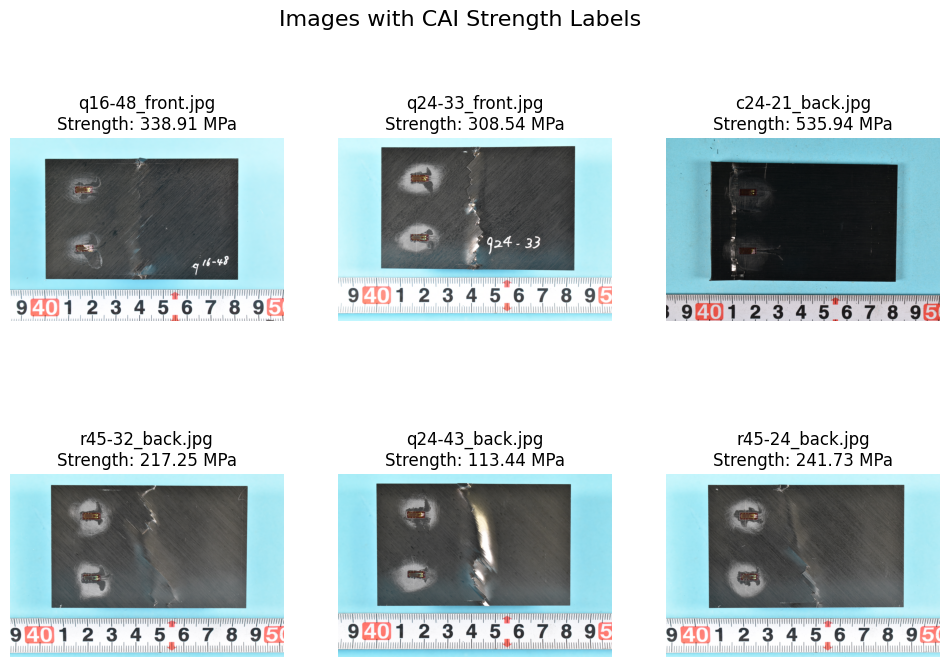

In [39]:
plt.figure(figsize=(12,8))

for i in range(6):
    idx = random.randint(0, len(data)-1)
    img_name, strength = data[idx]

    img_path = os.path.join(img_folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"{img_name}\nStrength: {strength:.2f} MPa")
    plt.axis("off")

plt.suptitle("Images with CAI Strength Labels", fontsize=16)
plt.show()

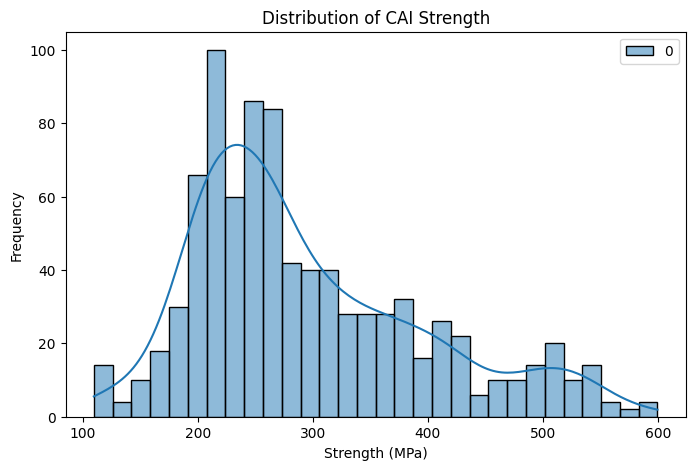

In [40]:
import seaborn as sns

y_real = scaler.inverse_transform(y)

plt.figure(figsize=(8,5))
sns.histplot(y_real, bins=30, kde=True)
plt.title("Distribution of CAI Strength")
plt.xlabel("Strength (MPa)")
plt.ylabel("Frequency")
plt.show()

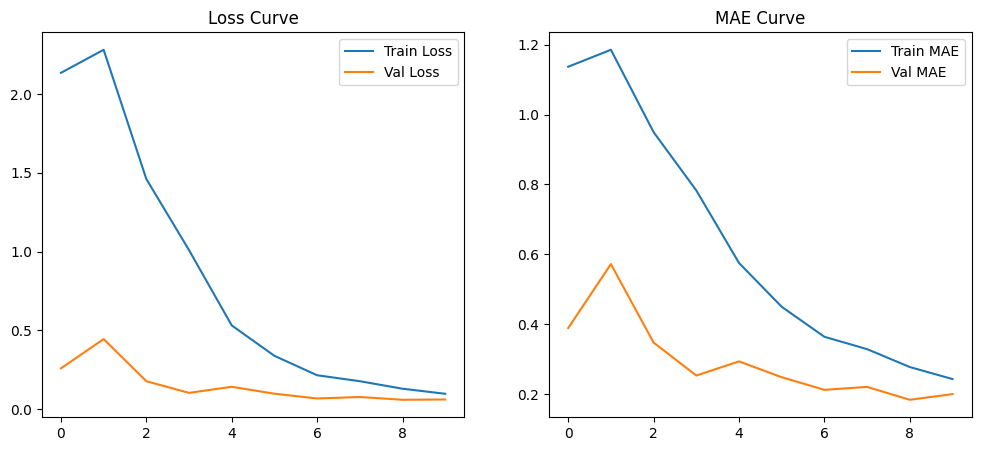

In [41]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

# MAE
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title("MAE Curve")
plt.legend()

plt.show()

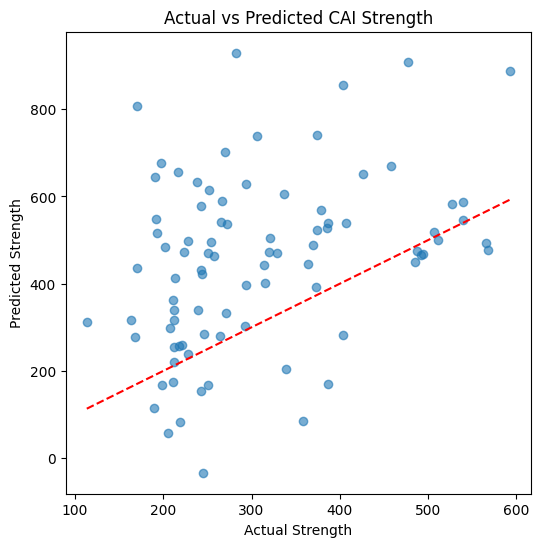

In [43]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_real, pred, alpha=0.6)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         'r--')

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted CAI Strength")
plt.show()

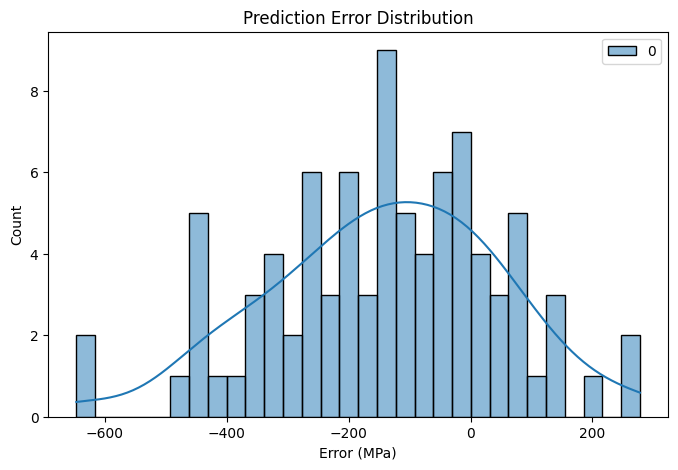

In [45]:
errors = y_test_real - pred

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (MPa)")
plt.show()

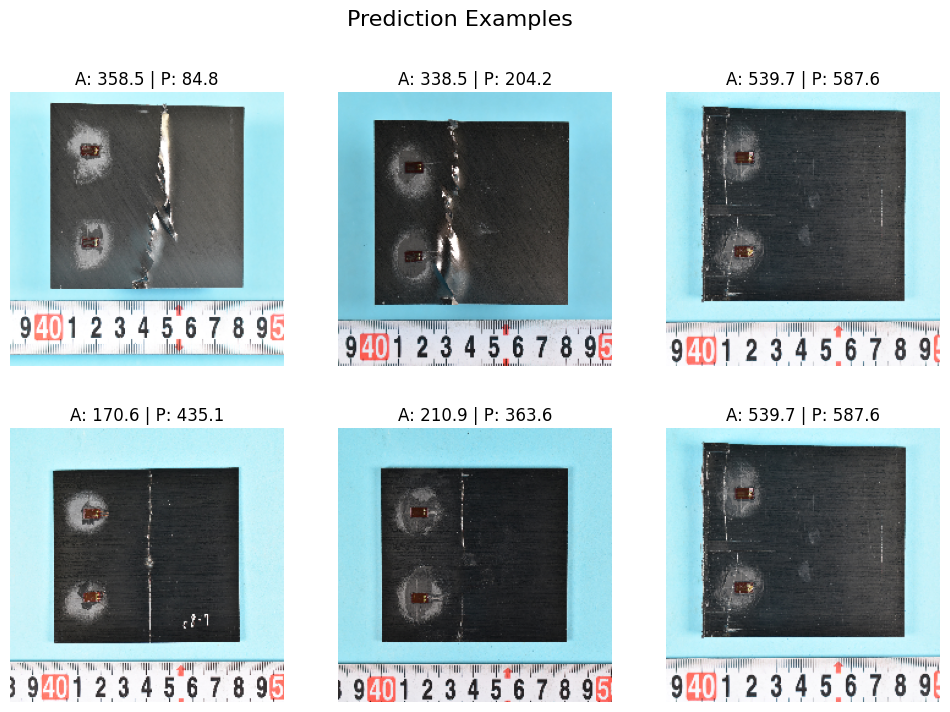

In [47]:
plt.figure(figsize=(12,8))

for i in range(6):
    idx = random.randint(0, len(X_test)-1)

    img = X_test[idx]
    actual = y_test_real[idx][0]
    predicted = pred[idx][0]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"A: {actual:.1f} | P: {predicted:.1f}")
    plt.axis("off")

plt.suptitle("Prediction Examples", fontsize=16)
plt.show()

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_real, pred)
mse = mean_squared_error(y_test_real, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 185.60328674316406
MSE: 55932.4609375
RMSE: 236.50044595623916
R2 Score: -3.3144116401672363
